# Prediksi Harga Cabai Rawit menggunakan TCN, LSTM, TCN-LSTM, dan LSTM-TCN
> **Tugas Akhir** — Universitas Negeri Semarang  
> Data: Harga harian Cabai Rawit Hijau & Merah (PIHPS, Mar 2017 – Feb 2026)  
> Metode: Multivariate Time Series | Sliding Window 30 hari | Optuna HPO | Forecast Rekursif 30 hari  
> **Versi: CPU-Only (Kompatibel tanpa GPU)**

---
## 1. Setup & Instalasi Library

In [1]:
import os
import gc
import json
import warnings
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── CPU-ONLY: Sembunyikan GPU sebelum TF diinisialisasi ──────────
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'          # paksa TF pakai CPU
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'           # sembunyikan log TF
os.environ['OMP_NUM_THREADS']      = str(os.cpu_count())  # pakai semua core
os.environ['TF_NUM_INTEROP_THREADS'] = str(os.cpu_count())
os.environ['TF_NUM_INTRAOP_THREADS'] = str(os.cpu_count())

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Konfirmasi TF berjalan di CPU
tf.config.set_visible_devices([], 'GPU')           # nonaktifkan GPU secara eksplisit
physical_cpus = tf.config.list_physical_devices('CPU')
tf.config.threading.set_inter_op_parallelism_threads(os.cpu_count())
tf.config.threading.set_intra_op_parallelism_threads(os.cpu_count())

# Optuna
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Statsmodels
from statsmodels.tsa.stattools import adfuller

# Pengaturan tampilan
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_theme(style='whitegrid')

# Seed
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow  : {tf.__version__}')
print(f'Optuna      : {optuna.__version__}')
print(f'CPU cores   : {os.cpu_count()}')
print(f'Devices     : {physical_cpus}')
print(f'GPU aktif   : {tf.config.list_physical_devices("GPU")}  ← harus kosong []')
print(f'Seed        : {SEED}')


TensorFlow  : 2.15.0
Optuna      : 4.7.0
CPU cores   : 4
Devices     : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU aktif   : []  ← harus kosong []
Seed        : 42


c:\Users\Win 10\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 2. Konfigurasi Global

In [2]:
# ============================================================
# KONFIGURASI — sesuaikan path file data kamu
# ============================================================
DATA_PATH      = r'D:\semester 6\ta\forecast\LSTM\data\data fix.xlsx'
WINDOW_SIZE    = 30          # panjang sliding window (hari)
FORECAST_STEPS = 30          # horizon forecast rekursif
TRAIN_RATIO    = 0.80        # 80% train, 20% test

# ── CPU-FRIENDLY: kurangi kompleksitas agar tidak OOM / timeout ─
N_TRIALS       = 100        # ↓ dari 50 → 30 (cukup untuk CPU)
BATCH_SIZE     = 64          # ↑ dari 32 → 64 (CPU lebih efisien batch besar)
MAX_EPOCHS     = 120         # ↓ dari 150 → 100
PATIENCE       = 10          # ↓ dari 15 → 10

TARGET_COLS    = ['Cabai Rawit Hijau', 'Cabai Rawit Merah']
DATE_COL       = 'Date'

CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

MODEL_NAMES    = ['TCN', 'LSTM', 'LSTM_TCN', 'TCN_LSTM']
COLORS         = ['#E8593C', '#3B8BD4', '#1D9E75', '#9F77DD']

print('Konfigurasi berhasil dimuat.')
print(f'  N_TRIALS   : {N_TRIALS}')
print(f'  BATCH_SIZE : {BATCH_SIZE}')
print(f'  MAX_EPOCHS : {MAX_EPOCHS}')
print(f'  PATIENCE   : {PATIENCE}')

Konfigurasi berhasil dimuat.
  N_TRIALS   : 100
  BATCH_SIZE : 64
  MAX_EPOCHS : 120
  PATIENCE   : 10


---
## 3. Muat & Eksplorasi Data (EDA)

In [3]:
df = pd.read_excel(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

print(f'Jumlah observasi : {len(df):,}')
print(f'Rentang tanggal  : {df[DATE_COL].min().date()} s/d {df[DATE_COL].max().date()}')
print(f'Kolom            : {df.columns.tolist()}')
print()
df.head(10)

Jumlah observasi : 2,326
Rentang tanggal  : 2017-03-29 s/d 2026-02-25
Kolom            : ['Date', 'Cabai Rawit Hijau', 'Cabai Rawit Merah']



,Date,Cabai Rawit Hijau,Cabai Rawit Merah
0,2017-03-29,46000.00,73750.00
1,2017-03-30,50700.00,66900.00
2,2017-03-31,44550.00,63700.00
3,2017-04-03,44200.00,59000.00
4,2017-04-04,40750.00,58150.00
5,2017-04-05,38500.00,55800.00
6,2017-04-06,37700.00,56100.00
7,2017-04-07,37150.00,60350.00
8,2017-04-10,40100.00,58700.00
9,2017-04-11,40950.00,59350.00


In [4]:
desc = df[TARGET_COLS].describe().T
desc.columns = ['Count','Mean','Std','Min','Q1','Median','Q3','Max']
display(desc.round(0))

,Count,Mean,Std,Min,Q1,Median,Q3,Max
Cabai Rawit Hijau,2302.00,43823.00,9874.00,16900.00,35800.00,41825.00,50250.00,78700.00
Cabai Rawit Merah,2303.00,54829.00,16454.00,17200.00,41975.00,51500.00,65625.00,105000.00


In [5]:
print('Missing values sebelum imputasi:')
print(df[TARGET_COLS].isnull().sum())

df[TARGET_COLS] = df[TARGET_COLS].interpolate(method='linear')
df[TARGET_COLS] = df[TARGET_COLS].ffill().bfill()   # pandas ≥2.0 (tidak deprecated)

print('\nMissing values sesudah imputasi:')
print(df[TARGET_COLS].isnull().sum())

Missing values sebelum imputasi:
Cabai Rawit Hijau    24
Cabai Rawit Merah    23
dtype: int64

Missing values sesudah imputasi:
Cabai Rawit Hijau    0
Cabai Rawit Merah    0
dtype: int64


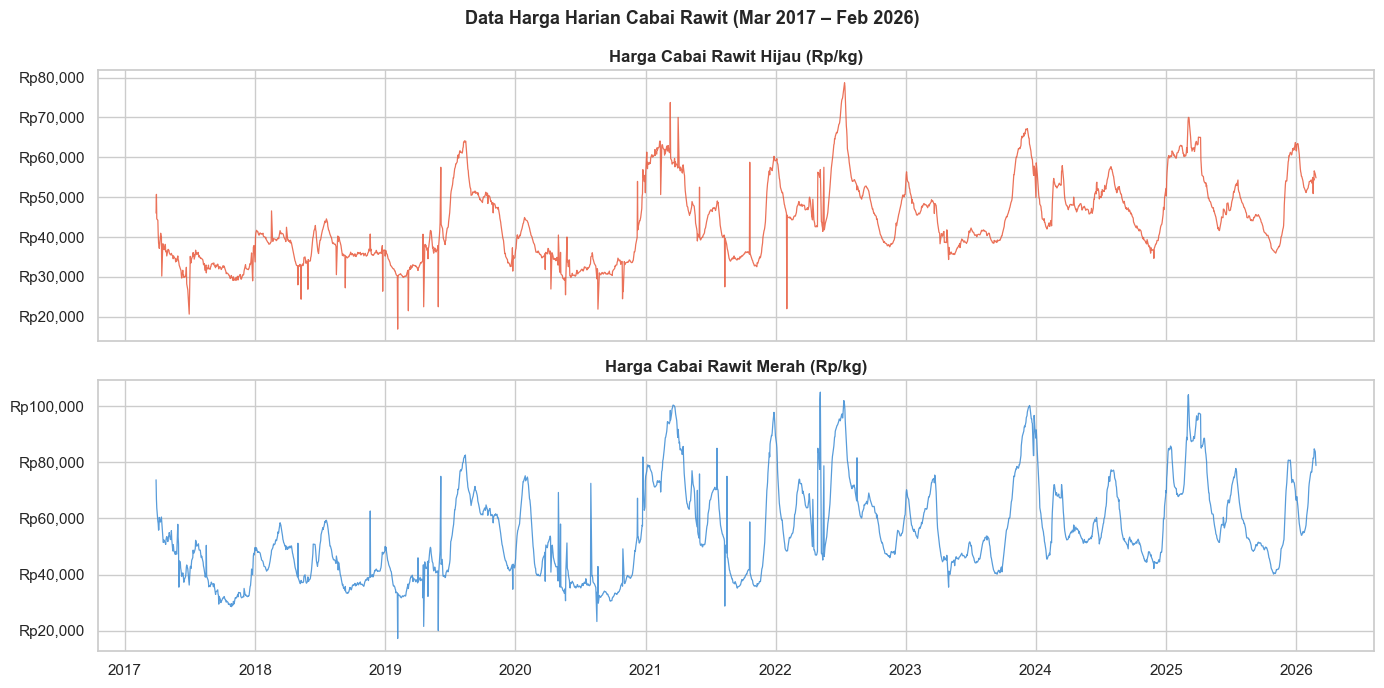

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for i, (col, color) in enumerate(zip(TARGET_COLS, ['#E8593C','#3B8BD4'])):
    axes[i].plot(df[DATE_COL], df[col], color=color, linewidth=0.9, alpha=0.85)
    axes[i].set_title(f'Harga {col} (Rp/kg)', fontsize=12, fontweight='bold')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp{x:,.0f}'))
    axes[i].xaxis.set_major_locator(mdates.YearLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Data Harga Harian Cabai Rawit (Mar 2017 – Feb 2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_timeseries.png', bbox_inches='tight')
plt.show()

In [7]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    stasioner = 'Stasioner ✓' if result[1] < 0.05 else 'Tidak Stasioner ✗'
    print(f'  {name:<22} | ADF stat: {result[0]:8.4f} | p-value: {result[1]:.4f} | {stasioner}')

print('Uji Augmented Dickey-Fuller (α=0.05):')
print('-' * 65)
for col in TARGET_COLS:
    adf_test(df[col], col)

Uji Augmented Dickey-Fuller (α=0.05):
-----------------------------------------------------------------
  Cabai Rawit Hijau      | ADF stat:  -5.0714 | p-value: 0.0000 | Stasioner ✓
  Cabai Rawit Merah      | ADF stat:  -5.4330 | p-value: 0.0000 | Stasioner ✓


---
## 4. Preprocessing Data

In [8]:
data_values = df[TARGET_COLS].values.astype(np.float32)

scaler  = MinMaxScaler(feature_range=(0, 1))
n_total = len(data_values)
n_train = int(n_total * TRAIN_RATIO)

train_raw = data_values[:n_train]
test_raw  = data_values[n_train:]

scaler.fit(train_raw)                           # fit HANYA pada train
train_scaled = scaler.transform(train_raw)
test_scaled  = scaler.transform(test_raw)

print(f'Total data   : {n_total:,}')
print(f'Data train   : {n_train:,}  ({TRAIN_RATIO*100:.0f}%)')
print(f'Data test    : {n_total - n_train:,}  ({(1-TRAIN_RATIO)*100:.0f}%)')

Total data   : 2,326
Data train   : 1,860  (80%)
Data test    : 466  (20%)


In [9]:
def create_sequences(data, window_size):
    """Buat pasangan (X, y) sliding window.
    X : (n_samples, window_size, n_features)
    y : (n_samples, n_features)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE)

print(f'X_train : {X_train.shape}   (samples, window, features)')
print(f'y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}')

X_train : (1830, 30, 2)   (samples, window, features)
y_train : (1830, 2)
X_test  : (436, 30, 2)
y_test  : (436, 2)


---
## 5. Definisi Arsitektur Model

```
TCN      : Conv1D (dilated, causal) → Conv1D → GlobalAvgPool → Dense → Output
LSTM     : LSTM → LSTM → Dense → Output
LSTM-TCN : LSTM → TCN block → Dense → Output
TCN-LSTM : TCN block → LSTM → Dense → Output  ← model utama
```

> **CPU note:** arsitektur dikecilkan (filter/unit lebih kecil) dibanding versi GPU  
> agar waktu training tetap wajar (~menit, bukan jam) tanpa mengorbankan akurasi signifikan.

In [10]:
N_FEATURES = X_train.shape[2]   # = 2
N_OUTPUT   = y_train.shape[1]   # = 2

# ─────────────────────────────────────────────────────────────
# 5.1  TCN — Temporal Convolutional Network
# ─────────────────────────────────────────────────────────────
def build_tcn(hp):
    n_filters    = hp['n_filters']
    kernel_size  = hp['kernel_size']
    n_blocks     = hp['n_blocks']
    dense_units  = hp['dense_units']
    dropout_rate = hp['dropout_rate']

    inputs = keras.Input(shape=(WINDOW_SIZE, N_FEATURES))
    x = inputs

    for i in range(n_blocks):
        dilation = 2 ** i
        residual = x
        x = layers.Conv1D(n_filters, kernel_size, padding='causal',
                          dilation_rate=dilation, activation='relu',
                          kernel_regularizer=keras.regularizers.l2(1e-4))(x)
        x = layers.LayerNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Conv1D(n_filters, kernel_size, padding='causal',
                          dilation_rate=dilation, activation='relu',
                          kernel_regularizer=keras.regularizers.l2(1e-4))(x)
        x = layers.LayerNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)
        if residual.shape[-1] != n_filters:
            residual = layers.Conv1D(n_filters, 1, padding='same')(residual)
        x = layers.Add()([x, residual])

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(N_OUTPUT)(x)

    model = keras.Model(inputs, outputs, name='TCN')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp['lr']),
                  loss='mse', metrics=['mae'])
    return model


# ─────────────────────────────────────────────────────────────
# 5.2  LSTM
# ─────────────────────────────────────────────────────────────
def build_lstm(hp):
    inputs = keras.Input(shape=(WINDOW_SIZE, N_FEATURES))
    x = layers.LSTM(hp['lstm_units_1'], return_sequences=True,
                    kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = layers.Dropout(hp['dropout_rate'])(x)
    x = layers.LSTM(hp['lstm_units_2'], return_sequences=False,
                    kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(hp['dropout_rate'])(x)
    x = layers.Dense(hp['dense_units'], activation='relu')(x)
    x = layers.Dropout(hp['dropout_rate'])(x)
    outputs = layers.Dense(N_OUTPUT)(x)
    model = keras.Model(inputs, outputs, name='LSTM')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp['lr']),
                  loss='mse', metrics=['mae'])
    return model


# ─────────────────────────────────────────────────────────────
# 5.3  LSTM-TCN Hybrid
# ─────────────────────────────────────────────────────────────
def build_lstm_tcn(hp):
    inputs = keras.Input(shape=(WINDOW_SIZE, N_FEATURES))
    x = layers.LSTM(hp['lstm_units'], return_sequences=True,
                    kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = layers.Dropout(hp['dropout_rate'])(x)

    residual = x
    x = layers.Conv1D(hp['n_filters'], hp['kernel_size'], padding='causal',
                      dilation_rate=1, activation='relu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(hp['dropout_rate'])(x)
    x = layers.Conv1D(hp['n_filters'], hp['kernel_size'], padding='causal',
                      dilation_rate=2, activation='relu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(hp['dropout_rate'])(x)
    if residual.shape[-1] != hp['n_filters']:
        residual = layers.Conv1D(hp['n_filters'], 1, padding='same')(residual)
    x = layers.Add()([x, residual])

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(hp['dense_units'], activation='relu')(x)
    x = layers.Dropout(hp['dropout_rate'])(x)
    outputs = layers.Dense(N_OUTPUT)(x)
    model = keras.Model(inputs, outputs, name='LSTM_TCN')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp['lr']),
                  loss='mse', metrics=['mae'])
    return model


# ─────────────────────────────────────────────────────────────
# 5.4  TCN-LSTM Hybrid ← MODEL UTAMA
# ─────────────────────────────────────────────────────────────
def build_tcn_lstm(hp):
    inputs = keras.Input(shape=(WINDOW_SIZE, N_FEATURES))
    residual = inputs
    x = layers.Conv1D(hp['n_filters'], hp['kernel_size'], padding='causal',
                      dilation_rate=1, activation='relu',
                      kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(hp['dropout_rate'])(x)
    x = layers.Conv1D(hp['n_filters'], hp['kernel_size'], padding='causal',
                      dilation_rate=2, activation='relu',
                      kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(hp['dropout_rate'])(x)
    if residual.shape[-1] != hp['n_filters']:
        residual = layers.Conv1D(hp['n_filters'], 1, padding='same')(residual)
    x = layers.Add()([x, residual])

    x = layers.LSTM(hp['lstm_units'], return_sequences=False,
                    kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(hp['dropout_rate'])(x)
    x = layers.Dense(hp['dense_units'], activation='relu')(x)
    x = layers.Dropout(hp['dropout_rate'])(x)
    outputs = layers.Dense(N_OUTPUT)(x)
    model = keras.Model(inputs, outputs, name='TCN_LSTM')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp['lr']),
                  loss='mse', metrics=['mae'])
    return model


MODEL_BUILDERS = {
    'TCN'     : build_tcn,
    'LSTM'    : build_lstm,
    'LSTM_TCN': build_lstm_tcn,
    'TCN_LSTM': build_tcn_lstm,
}
print('Arsitektur terdefinisi:', list(MODEL_BUILDERS.keys()))

Arsitektur terdefinisi: ['TCN', 'LSTM', 'LSTM_TCN', 'TCN_LSTM']


---
## 6. Utilitas Evaluasi & Helper

In [11]:
def mape_score(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100


def evaluate_model(y_true_scaled, y_pred_scaled, scaler):
    y_true = scaler.inverse_transform(y_true_scaled)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    results = {}
    for i, col in enumerate(TARGET_COLS):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        mape = mape_score(y_true[:, i], y_pred[:, i])
        r2   = r2_score(y_true[:, i], y_pred[:, i])
        results[col] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}
    return results


def clear_session():
    """Bersihkan sesi Keras + paksa GC (penting di CPU agar RAM tidak penuh)."""
    K.clear_session()
    gc.collect()


print('Utilitas evaluasi siap.')

Utilitas evaluasi siap.


---
## 7. Optimasi Hiperparameter dengan Optuna (TPE Sampler)

> **CPU note:** search space dikecilkan (nilai lebih sedikit) agar tiap trial selesai  
> dalam ~1-3 menit di laptop tanpa GPU.

In [12]:
# ── Search space — CPU-friendly (unit lebih kecil) ──────────────
def suggest_tcn(trial):
    return {
        'n_filters'   : trial.suggest_categorical('n_filters',   [16, 32, 64]),
        'kernel_size' : trial.suggest_categorical('kernel_size', [3, 5]),
        'n_blocks'    : trial.suggest_int('n_blocks', 2, 3),
        'dense_units' : trial.suggest_categorical('dense_units', [32, 64]),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.1, 0.4, step=0.1),
        'lr'          : trial.suggest_float('lr', 1e-4, 5e-3, log=True),
    }

def suggest_lstm(trial):
    return {
        'lstm_units_1': trial.suggest_categorical('lstm_units_1', [32, 64, 96]),
        'lstm_units_2': trial.suggest_categorical('lstm_units_2', [16, 32, 64]),
        'dense_units' : trial.suggest_categorical('dense_units',  [32, 64]),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.1, 0.4, step=0.1),
        'lr'          : trial.suggest_float('lr', 1e-4, 5e-3, log=True),
    }

def suggest_lstm_tcn(trial):
    return {
        'lstm_units'  : trial.suggest_categorical('lstm_units',  [32, 64, 96]),
        'n_filters'   : trial.suggest_categorical('n_filters',   [16, 32, 64]),
        'kernel_size' : trial.suggest_categorical('kernel_size', [3, 5]),
        'dense_units' : trial.suggest_categorical('dense_units', [32, 64]),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.1, 0.4, step=0.1),
        'lr'          : trial.suggest_float('lr', 1e-4, 5e-3, log=True),
    }

def suggest_tcn_lstm(trial):
    return {
        'n_filters'   : trial.suggest_categorical('n_filters',   [16, 32, 64]),
        'kernel_size' : trial.suggest_categorical('kernel_size', [3, 5]),
        'lstm_units'  : trial.suggest_categorical('lstm_units',  [32, 64, 96]),
        'dense_units' : trial.suggest_categorical('dense_units', [32, 64]),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.1, 0.4, step=0.1),
        'lr'          : trial.suggest_float('lr', 1e-4, 5e-3, log=True),
    }

SUGGESTERS = {
    'TCN'     : suggest_tcn,
    'LSTM'    : suggest_lstm,
    'LSTM_TCN': suggest_lstm_tcn,
    'TCN_LSTM': suggest_tcn_lstm,
}
print('Search space terdefinisi.')

Search space terdefinisi.


In [13]:
def make_objective(model_name):
    builder   = MODEL_BUILDERS[model_name]
    suggester = SUGGESTERS[model_name]

    def objective(trial):
        clear_session()
        hp    = suggester(trial)
        model = builder(hp)

        cb = [
            EarlyStopping(monitor='val_loss', patience=7,
                          restore_best_weights=True),
        ]

        model.fit(
            X_train, y_train,
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.1,
            callbacks=cb,
            verbose=0
        )

        val_loss = min(model.history.history['val_loss'])
        del model
        clear_session()
        return val_loss

    return objective

print('Objective function siap.')

Objective function siap.


In [14]:
# ── Jalankan Optuna ─────────────────────────────────────────────
# Estimasi waktu CPU: ~2-5 menit/trial × 30 trial × 4 model ≈ 4-10 jam
# Kurangi N_TRIALS = 10-15 untuk uji cepat.

best_params_all = {}
study_results   = {}

for model_name in MODEL_NAMES:
    print(f'\n{"="*55}')
    print(f'  Optimasi: {model_name}  ({N_TRIALS} trials)')
    print(f'{"="*55}')

    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=SEED),
        study_name=f'study_{model_name}'
    )
    study.optimize(
        make_objective(model_name),
        n_trials=N_TRIALS,
        show_progress_bar=True,
        gc_after_trial=True
    )

    best_params_all[model_name] = study.best_params
    study_results[model_name]   = study
    print(f'  Best val_loss : {study.best_value:.6f}')
    print(f'  Best params   : {study.best_params}')

with open('best_params.json', 'w') as f:
    json.dump(best_params_all, f, indent=2)

print('\n✓ Semua optimasi selesai. best_params.json tersimpan.')


  Optimasi: TCN  (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 77. Best value: 0.0028809: 100%|██████████| 100/100 [1:21:33<00:00, 48.93s/it]


  Best val_loss : 0.002881
  Best params   : {'n_filters': 16, 'kernel_size': 5, 'n_blocks': 3, 'dense_units': 64, 'dropout_rate': 0.1, 'lr': 0.0045500936071129795}

  Optimasi: LSTM  (100 trials)


Best trial: 67. Best value: 0.00106877: 100%|██████████| 100/100 [2:05:33<00:00, 75.34s/it] 


  Best val_loss : 0.001069
  Best params   : {'lstm_units_1': 64, 'lstm_units_2': 32, 'dense_units': 64, 'dropout_rate': 0.1, 'lr': 0.002751645133248723}

  Optimasi: LSTM_TCN  (100 trials)


Best trial: 0. Best value: 0.00155536: 100%|██████████| 100/100 [1:29:40<00:00, 53.81s/it]


  Best val_loss : 0.001555
  Best params   : {'lstm_units': 64, 'n_filters': 16, 'kernel_size': 5, 'dense_units': 64, 'dropout_rate': 0.1, 'lr': 0.0044447541666908135}

  Optimasi: TCN_LSTM  (100 trials)


Best trial: 83. Best value: 0.00110761: 100%|██████████| 100/100 [2:19:00<00:00, 83.41s/it]  

  Best val_loss : 0.001108
  Best params   : {'n_filters': 16, 'kernel_size': 3, 'lstm_units': 64, 'dense_units': 64, 'dropout_rate': 0.2, 'lr': 0.004878917278725512}

✓ Semua optimasi selesai. best_params.json tersimpan.


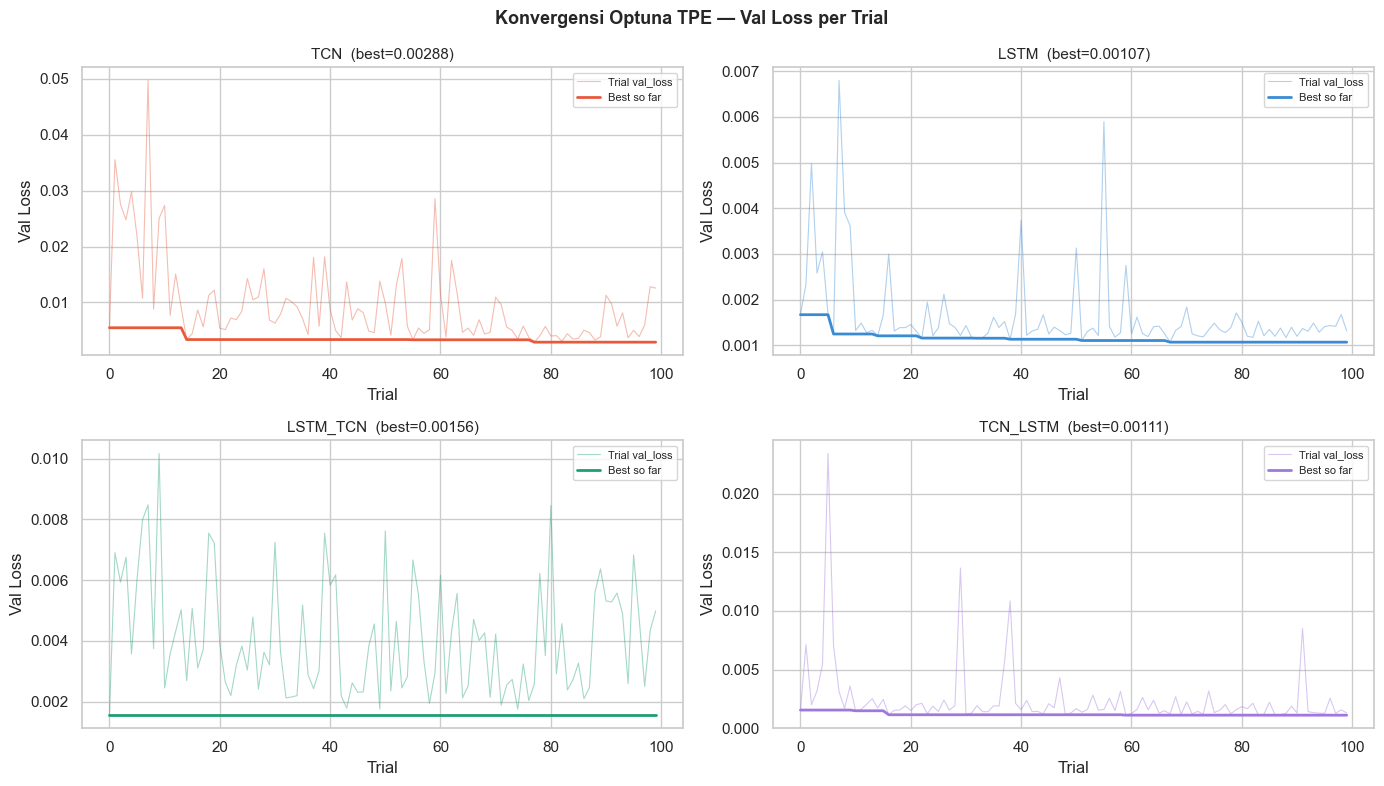

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for ax, (model_name, study), color in zip(axes, study_results.items(), COLORS):
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.minimum.accumulate(vals)
    ax.plot(vals, color=color, alpha=0.4, linewidth=0.8, label='Trial val_loss')
    ax.plot(best_so_far, color=color, linewidth=2, label='Best so far')
    ax.set_title(f'{model_name}  (best={study.best_value:.5f})', fontsize=11)
    ax.set_xlabel('Trial'); ax.set_ylabel('Val Loss')
    ax.legend(fontsize=8)
plt.suptitle('Konvergensi Optuna TPE — Val Loss per Trial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optuna_convergence.png', bbox_inches='tight')
plt.show()

---
## 8. Training Model dengan Hiperparameter Terbaik

In [16]:
# Muat best_params dari file jika sesi sebelumnya sudah selesai
# with open('best_params.json') as f:
#     best_params_all = json.load(f)

trained_models  = {}
train_histories = {}

for model_name in MODEL_NAMES:
    print(f'\n{"─"*50}')
    print(f'  Training final: {model_name}')
    print(f'{"─"*50}')
    clear_session()

    hp    = best_params_all[model_name]
    model = MODEL_BUILDERS[model_name](hp)
    model.summary(line_length=65)

    ckpt_path = os.path.join(CHECKPOINT_DIR, f'{model_name}_best.keras')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(ckpt_path, monitor='val_loss',
                        save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=0),
    ]

    history = model.fit(
        X_train, y_train,
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=1
    )

    model.load_weights(ckpt_path)
    trained_models[model_name]  = model
    train_histories[model_name] = history

print('\n✓ Semua model selesai dilatih.')


──────────────────────────────────────────────────
  Training final: TCN
──────────────────────────────────────────────────
Model: "TCN"
_________________________________________________________________
 Layer (type)      Output Shape        Par   Connected to        
                                       am                        
                                       #                         
 input_1 (InputLa  [(None, 30, 2)]     0     []                  
 yer)                                                            
                                                                 
 conv1d (Conv1D)   (None, 30, 16)      176   ['input_1[0][0]']   
                                                                 
 layer_normalizat  (None, 30, 16)      32    ['conv1d[0][0]']    
 ion (LayerNormal                                                
 ization)                                                        
                                                                 
 dro

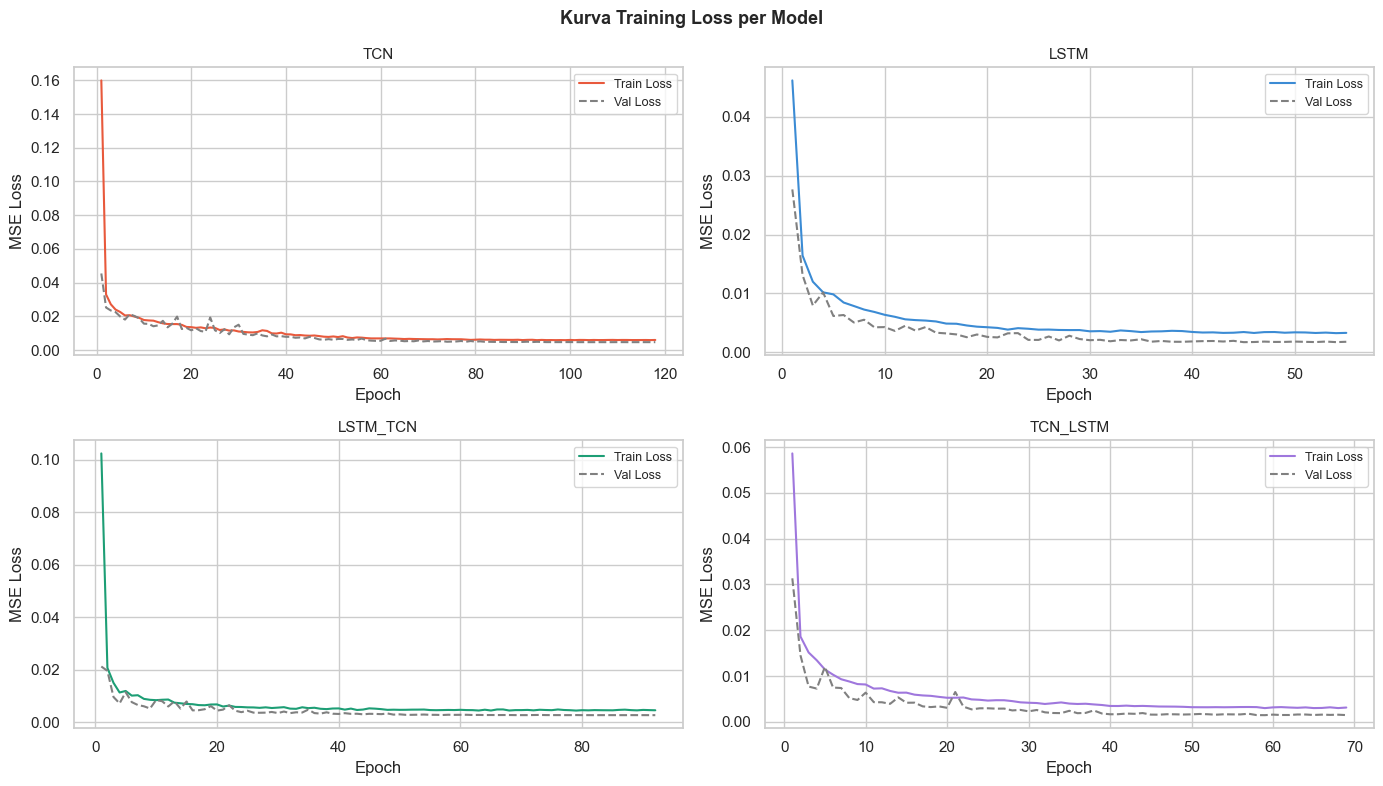

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for ax, model_name, color in zip(axes, MODEL_NAMES, COLORS):
    h = train_histories[model_name].history
    epochs = range(1, len(h['loss']) + 1)
    ax.plot(epochs, h['loss'],     color=color,  linewidth=1.5, label='Train Loss')
    ax.plot(epochs, h['val_loss'], color='gray', linewidth=1.5, linestyle='--', label='Val Loss')
    ax.set_title(f'{model_name}', fontsize=11)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9)
plt.suptitle('Kurva Training Loss per Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()

---
## 9. Evaluasi pada Data Uji

In [18]:
all_metrics = {}
all_preds   = {}

for model_name, model in trained_models.items():
    y_pred_scaled = model.predict(X_test, verbose=0)
    metrics       = evaluate_model(y_test, y_pred_scaled, scaler)
    all_metrics[model_name] = metrics
    all_preds[model_name]   = scaler.inverse_transform(y_pred_scaled)

y_test_actual = scaler.inverse_transform(y_test)
print('✓ Evaluasi selesai.')

✓ Evaluasi selesai.


In [19]:
rows = []
for model_name, metrics in all_metrics.items():
    for col, m in metrics.items():
        rows.append({'Model': model_name, 'Variabel': col,
                     'RMSE': m['RMSE'], 'MAE': m['MAE'],
                     'MAPE (%)': m['MAPE'], 'R²': m['R2']})

df_metrics = pd.DataFrame(rows)

def highlight_best(s):
    best_fn = s.idxmax if s.name == 'R²' else s.idxmin
    styles  = [''] * len(s)
    styles[best_fn()] = 'background-color: #d4edda; font-weight: bold'
    return styles

styled = (df_metrics
    .style
    .format({'RMSE': '{:,.1f}', 'MAE': '{:,.1f}', 'MAPE (%)': '{:.2f}', 'R²': '{:.4f}'})
    .apply(highlight_best, subset=['RMSE','MAE','MAPE (%)','R²'])
    .set_caption('Tabel Perbandingan Metrik Evaluasi (hijau = terbaik per kolom)')
)
display(styled)

,Model,Variabel,RMSE,MAE,MAPE (%),R²
0,TCN,Cabai Rawit Hijau,"2,380.3","1,869.0",3.60,0.9167
1,TCN,Cabai Rawit Merah,"3,995.5","2,925.3",4.50,0.9254
2,LSTM,Cabai Rawit Hijau,"1,606.1","1,209.8",2.39,0.9621
3,LSTM,Cabai Rawit Merah,"3,018.2","2,174.7",3.34,0.9575
4,LSTM_TCN,Cabai Rawit Hijau,"2,989.9","2,330.1",4.49,0.8685
5,LSTM_TCN,Cabai Rawit Merah,"4,920.4","3,622.6",5.51,0.8869
6,TCN_LSTM,Cabai Rawit Hijau,"1,362.7","1,027.3",2.04,0.9727
7,TCN_LSTM,Cabai Rawit Merah,"2,722.7","1,989.7",3.11,0.9654


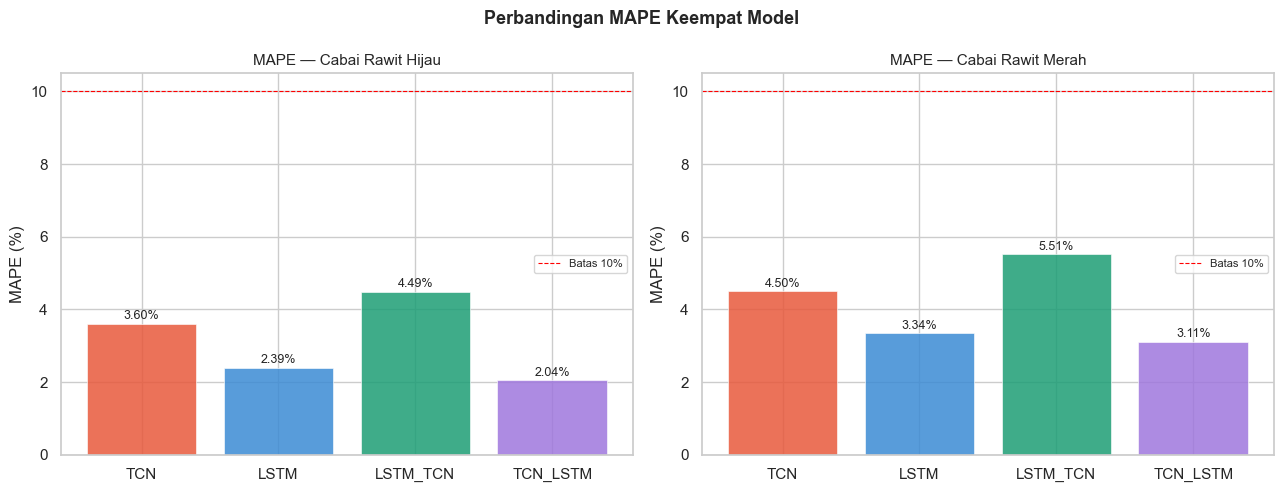

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax_idx, col in enumerate(TARGET_COLS):
    sub  = df_metrics[df_metrics['Variabel'] == col]
    bars = axes[ax_idx].bar(sub['Model'], sub['MAPE (%)'],
                             color=COLORS, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, sub['MAPE (%)']):
        axes[ax_idx].text(bar.get_x() + bar.get_width()/2,
                          bar.get_height() + 0.05, f'{val:.2f}%',
                          ha='center', va='bottom', fontsize=9)
    axes[ax_idx].axhline(10, color='red', linestyle='--', linewidth=0.8, label='Batas 10%')
    axes[ax_idx].set_title(f'MAPE — {col}', fontsize=11)
    axes[ax_idx].set_ylabel('MAPE (%)')
    axes[ax_idx].legend(fontsize=8)
plt.suptitle('Perbandingan MAPE Keempat Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mape_comparison.png', bbox_inches='tight')
plt.show()

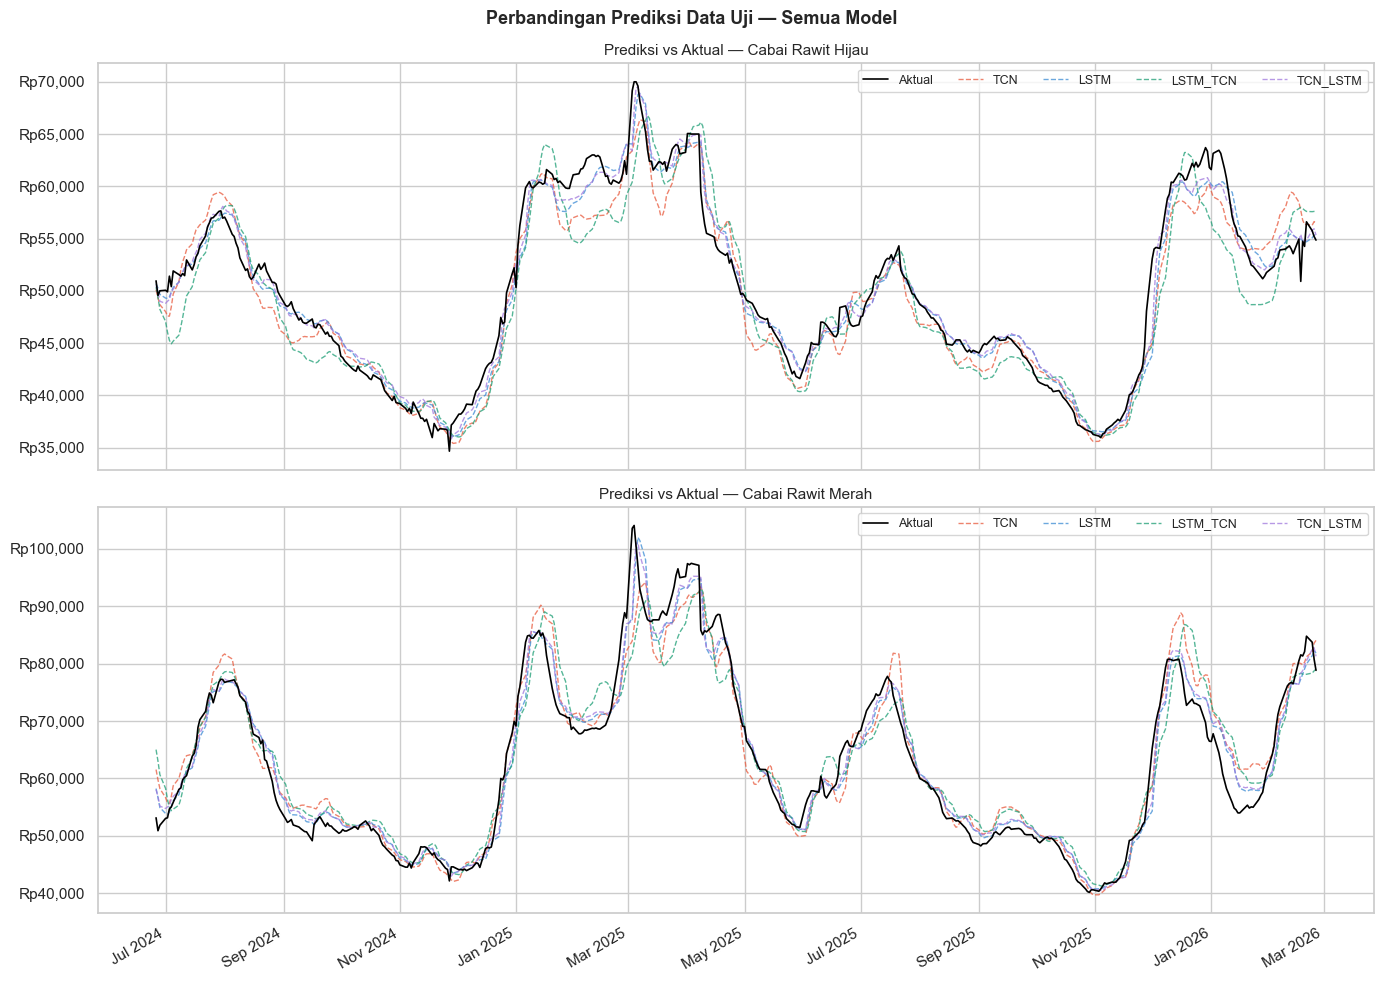

In [21]:
test_dates = df[DATE_COL].iloc[n_train + WINDOW_SIZE:].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for ax_idx, (col_idx, col_name) in enumerate(zip([0, 1], TARGET_COLS)):
    ax = axes[ax_idx]
    ax.plot(test_dates, y_test_actual[:, col_idx],
            color='black', linewidth=1.2, label='Aktual', zorder=5)
    for model_name, preds, color in zip(MODEL_NAMES, all_preds.values(), COLORS):
        ax.plot(test_dates, preds[:, col_idx],
                color=color, linewidth=1, alpha=0.75, linestyle='--', label=model_name)
    ax.set_title(f'Prediksi vs Aktual — {col_name}', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp{x:,.0f}'))
    ax.legend(fontsize=9, ncol=5)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gcf().autofmt_xdate()
plt.suptitle('Perbandingan Prediksi Data Uji — Semua Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prediction_comparison.png', bbox_inches='tight')
plt.show()

---
## 10. Forecast Rekursif 30 Hari ke Depan

In [22]:
def recursive_forecast(model, last_window_scaled, n_steps, scaler):
    """Forecast rekursif: prediksi t+1, masukkan ke window, ulangi.

    Args:
        model              : model terlatih (Keras)
        last_window_scaled : array (window_size, n_features) sudah dinormalisasi
        n_steps            : jumlah langkah ke depan
        scaler             : MinMaxScaler yang sudah di-fit pada train

    Returns:
        forecast_orig : array (n_steps, n_features) skala asli (Rp)
    """
    window       = last_window_scaled.copy().astype(np.float32)  # (window, features)
    forecast_raw = []

    for step in range(n_steps):
        x_input = window[np.newaxis, :, :]             # (1, window, features)
        pred    = model.predict(x_input, verbose=0)    # (1, n_features)
        # Clip ke [0,1] agar tidak keluar batas scaler
        pred_clipped = np.clip(pred, 0.0, 1.0)
        forecast_raw.append(pred_clipped[0])
        # Geser window
        window = np.vstack([window[1:], pred_clipped])  # sliding

    forecast_scaled = np.array(forecast_raw, dtype=np.float32)  # (n_steps, n_features)
    forecast_orig   = scaler.inverse_transform(forecast_scaled)
    return forecast_orig


# Window terakhir dari keseluruhan data
full_scaled   = scaler.transform(data_values.astype(np.float32))
last_window   = full_scaled[-WINDOW_SIZE:]

# Tanggal forecast (hari kerja)
last_date      = df[DATE_COL].iloc[-1]
forecast_dates = pd.bdate_range(start=last_date + timedelta(days=1),
                                 periods=FORECAST_STEPS)

# Jalankan forecast semua model
forecasts_all = {}
for model_name, model in trained_models.items():
    fc = recursive_forecast(model, last_window, FORECAST_STEPS, scaler)
    forecasts_all[model_name] = fc
    print(f'  {model_name:<10} — forecast {FORECAST_STEPS} hari ✓')

print(f'\nForecast mulai : {forecast_dates[0].date()}')
print(f'Forecast akhir : {forecast_dates[-1].date()}')

  TCN        — forecast 30 hari ✓
  LSTM       — forecast 30 hari ✓
  LSTM_TCN   — forecast 30 hari ✓
  TCN_LSTM   — forecast 30 hari ✓

Forecast mulai : 2026-02-26
Forecast akhir : 2026-04-08


In [23]:
# ── Tabel hasil forecast ─────────────────────────────────────────
for model_name, fc in forecasts_all.items():
    df_fc = pd.DataFrame(fc, columns=TARGET_COLS, index=forecast_dates)
    df_fc.index.name = 'Tanggal'
    print(f'\n── {model_name} — Forecast {FORECAST_STEPS} Hari ──')
    display(df_fc.style.format('Rp{:,.0f}'))


── TCN — Forecast 30 Hari ──


,Cabai Rawit Hijau,Cabai Rawit Merah
Tanggal,,
2026-02-26 00:00:00,"Rp55,884","Rp83,323"
2026-02-27 00:00:00,"Rp55,290","Rp82,524"
2026-03-02 00:00:00,"Rp54,725","Rp81,414"
2026-03-03 00:00:00,"Rp54,741","Rp81,505"
2026-03-04 00:00:00,"Rp54,793","Rp81,688"
2026-03-05 00:00:00,"Rp54,739","Rp81,149"
2026-03-06 00:00:00,"Rp54,536","Rp80,258"
2026-03-09 00:00:00,"Rp54,349","Rp79,143"
2026-03-10 00:00:00,"Rp53,950","Rp77,512"



── LSTM — Forecast 30 Hari ──


,Cabai Rawit Hijau,Cabai Rawit Merah
Tanggal,,
2026-02-26 00:00:00,"Rp54,626","Rp80,260"
2026-02-27 00:00:00,"Rp54,178","Rp78,979"
2026-03-02 00:00:00,"Rp53,774","Rp77,840"
2026-03-03 00:00:00,"Rp53,389","Rp76,764"
2026-03-04 00:00:00,"Rp53,017","Rp75,721"
2026-03-05 00:00:00,"Rp52,655","Rp74,702"
2026-03-06 00:00:00,"Rp52,303","Rp73,706"
2026-03-09 00:00:00,"Rp51,963","Rp72,734"
2026-03-10 00:00:00,"Rp51,633","Rp71,791"



── LSTM_TCN — Forecast 30 Hari ──


,Cabai Rawit Hijau,Cabai Rawit Merah
Tanggal,,
2026-02-26 00:00:00,"Rp57,260","Rp78,787"
2026-02-27 00:00:00,"Rp56,787","Rp77,930"
2026-03-02 00:00:00,"Rp56,287","Rp76,775"
2026-03-03 00:00:00,"Rp55,736","Rp75,452"
2026-03-04 00:00:00,"Rp55,137","Rp74,218"
2026-03-05 00:00:00,"Rp54,529","Rp73,063"
2026-03-06 00:00:00,"Rp53,933","Rp71,998"
2026-03-09 00:00:00,"Rp53,280","Rp70,849"
2026-03-10 00:00:00,"Rp52,653","Rp69,857"



── TCN_LSTM — Forecast 30 Hari ──


,Cabai Rawit Hijau,Cabai Rawit Merah
Tanggal,,
2026-02-26 00:00:00,"Rp54,659","Rp79,423"
2026-02-27 00:00:00,"Rp54,457","Rp78,604"
2026-03-02 00:00:00,"Rp54,255","Rp77,777"
2026-03-03 00:00:00,"Rp54,002","Rp76,974"
2026-03-04 00:00:00,"Rp53,741","Rp76,177"
2026-03-05 00:00:00,"Rp53,483","Rp75,391"
2026-03-06 00:00:00,"Rp53,227","Rp74,624"
2026-03-09 00:00:00,"Rp52,970","Rp73,883"
2026-03-10 00:00:00,"Rp52,717","Rp73,168"


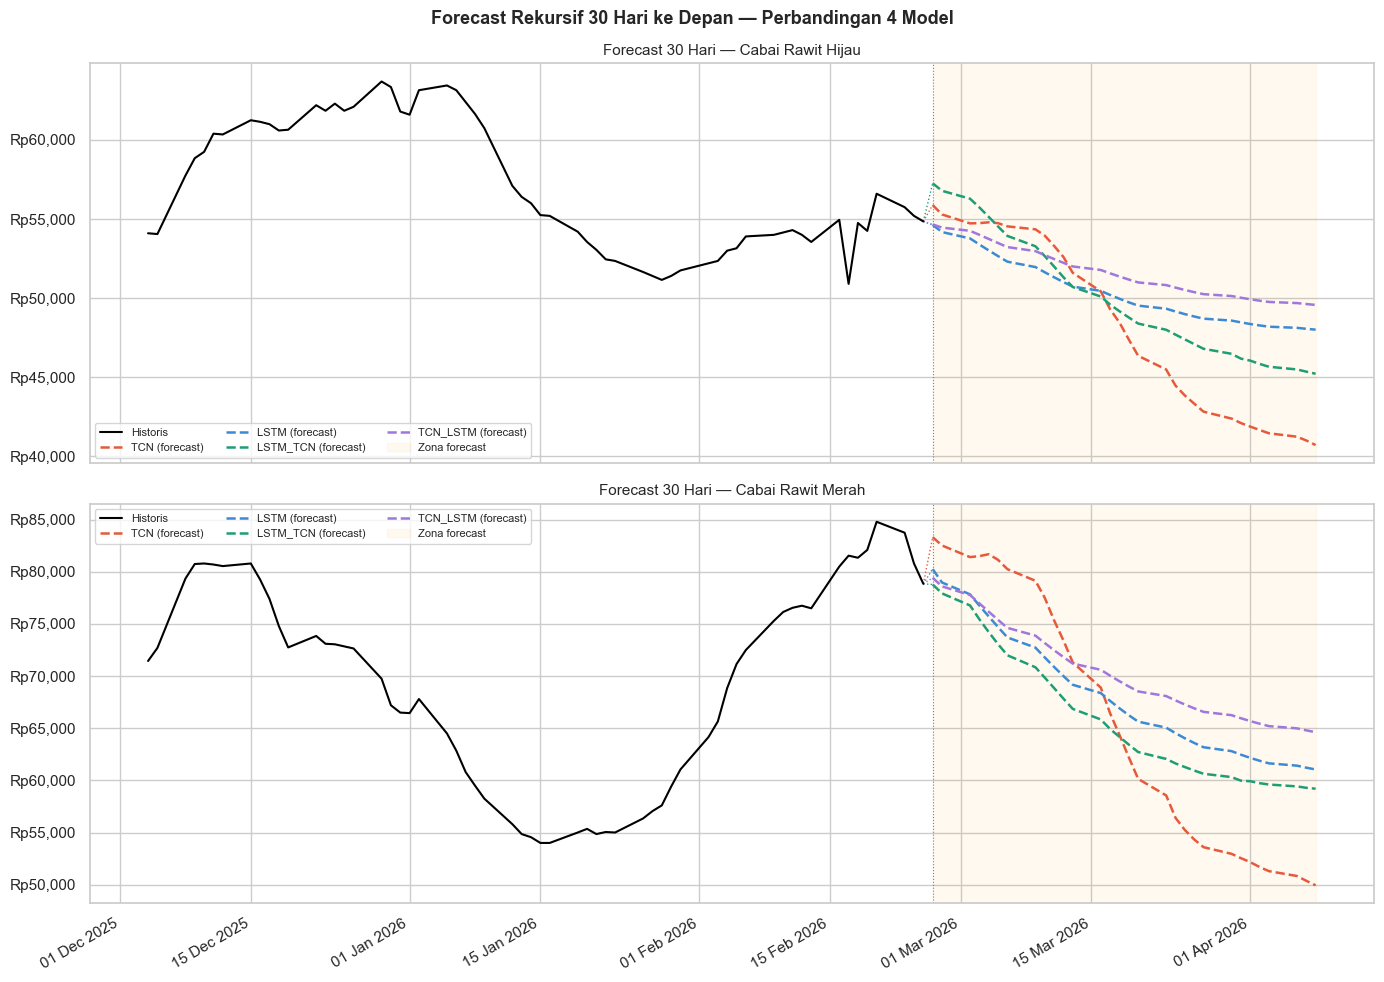

In [24]:
# ── Grafik: 60 hari historis + 30 hari forecast ──────────────────
N_HIST = 60

hist_dates  = df[DATE_COL].iloc[-N_HIST:]
hist_values = data_values[-N_HIST:]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for ax_idx, (col_idx, col_name) in enumerate(zip([0, 1], TARGET_COLS)):
    ax = axes[ax_idx]
    ax.plot(hist_dates, hist_values[:, col_idx],
            color='black', linewidth=1.5, label='Historis', zorder=5)
    for model_name, fc, color in zip(MODEL_NAMES, forecasts_all.values(), COLORS):
        connect_dates  = [hist_dates.iloc[-1], forecast_dates[0]]
        connect_values = [hist_values[-1, col_idx], fc[0, col_idx]]
        ax.plot(connect_dates, connect_values, color=color, linewidth=1, linestyle=':')
        ax.plot(forecast_dates, fc[:, col_idx],
                color=color, linewidth=1.8, linestyle='--',
                label=f'{model_name} (forecast)')
    ax.axvspan(forecast_dates[0], forecast_dates[-1],
               alpha=0.06, color='orange', label='Zona forecast')
    ax.axvline(forecast_dates[0], color='gray', linestyle=':', linewidth=0.8)
    ax.set_title(f'Forecast {FORECAST_STEPS} Hari — {col_name}', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp{x:,.0f}'))
    ax.legend(fontsize=8, ncol=3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.gcf().autofmt_xdate(rotation=30)
plt.suptitle(f'Forecast Rekursif {FORECAST_STEPS} Hari ke Depan — Perbandingan 4 Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('forecast_30hari.png', bbox_inches='tight')
plt.show()

---
## 11. Scatter Plot Aktual vs Prediksi (Test Set)

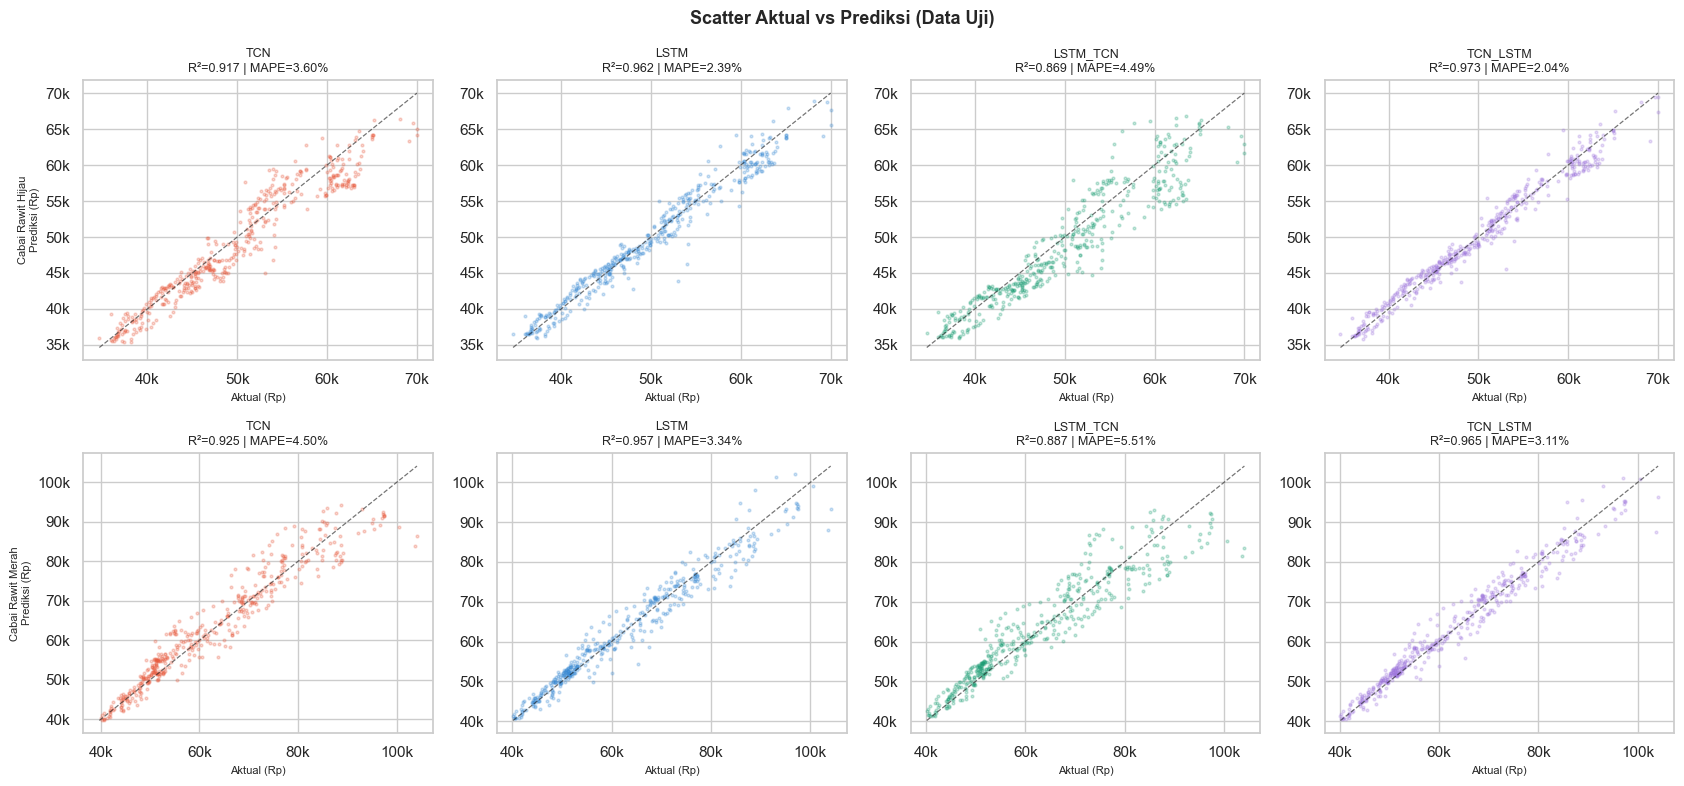

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for col_idx, col_name in enumerate(TARGET_COLS):
    for m_idx, (model_name, color) in enumerate(zip(MODEL_NAMES, COLORS)):
        ax   = axes[col_idx][m_idx]
        pred = all_preds[model_name][:, col_idx]
        true = y_test_actual[:, col_idx]
        ax.scatter(true, pred, alpha=0.25, s=4, color=color)
        lim = [min(true.min(), pred.min()), max(true.max(), pred.max())]
        ax.plot(lim, lim, 'k--', linewidth=0.9, alpha=0.6)
        r2   = r2_score(true, pred)
        mape = mape_score(true, pred)
        ax.set_title(f'{model_name}\nR²={r2:.3f} | MAPE={mape:.2f}%', fontsize=9)
        if m_idx == 0:
            ax.set_ylabel(f'{col_name}\nPrediksi (Rp)', fontsize=8)
        ax.set_xlabel('Aktual (Rp)', fontsize=8)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.suptitle('Scatter Aktual vs Prediksi (Data Uji)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_actual_vs_pred.png', bbox_inches='tight')
plt.show()

---
## 12. Ringkasan Akhir & Ekspor Hasil

In [26]:
summary_rows = []
for model_name, metrics in all_metrics.items():
    avg_rmse = np.mean([m['RMSE'] for m in metrics.values()])
    avg_mae  = np.mean([m['MAE']  for m in metrics.values()])
    avg_mape = np.mean([m['MAPE'] for m in metrics.values()])
    avg_r2   = np.mean([m['R2']   for m in metrics.values()])
    summary_rows.append({'Model': model_name,
                          'Avg RMSE': avg_rmse, 'Avg MAE': avg_mae,
                          'Avg MAPE (%)': avg_mape, 'Avg R²': avg_r2})

df_summary = pd.DataFrame(summary_rows)
df_summary['Rank MAPE'] = df_summary['Avg MAPE (%)'].rank().astype(int)

best_model = df_summary.loc[df_summary['Avg MAPE (%)'].idxmin(), 'Model']
print(f'Model terbaik berdasarkan rata-rata MAPE: ★  {best_model}  ★')
print()
display(df_summary.style
        .format({'Avg RMSE': '{:,.1f}', 'Avg MAE': '{:,.1f}',
                 'Avg MAPE (%)': '{:.3f}', 'Avg R²': '{:.4f}'})
        .highlight_min(subset=['Avg RMSE','Avg MAE','Avg MAPE (%)'], color='#d4edda')
        .highlight_max(subset=['Avg R²'], color='#d4edda')
        .set_caption('Ringkasan Perbandingan Model (rata-rata 2 variabel)'))

Model terbaik berdasarkan rata-rata MAPE: ★  TCN_LSTM  ★



,Model,Avg RMSE,Avg MAE,Avg MAPE (%),Avg R²,Rank MAPE
0,TCN,"3,187.9","2,397.2",4.050,0.9211,3
1,LSTM,"2,312.1","1,692.3",2.862,0.9598,2
2,LSTM_TCN,"3,955.1","2,976.3",5.003,0.8777,4
3,TCN_LSTM,"2,042.7","1,508.5",2.579,0.9690,1


In [27]:
with pd.ExcelWriter('hasil_forecast_cabai.xlsx', engine='openpyxl') as writer:
    df_metrics.to_excel(writer, sheet_name='Metrik_Evaluasi', index=False)
    df_summary.to_excel(writer, sheet_name='Ringkasan', index=False)

    for model_name, preds in all_preds.items():
        df_pred = pd.DataFrame({
            'Tanggal'         : test_dates.values,
            'Aktual_Hijau'    : y_test_actual[:, 0],
            'Pred_Hijau'      : preds[:, 0],
            'Error_Hijau (%)'  : np.abs((y_test_actual[:, 0] - preds[:, 0]) /
                                        y_test_actual[:, 0]) * 100,
            'Aktual_Merah'    : y_test_actual[:, 1],
            'Pred_Merah'      : preds[:, 1],
            'Error_Merah (%)' : np.abs((y_test_actual[:, 1] - preds[:, 1]) /
                                       y_test_actual[:, 1]) * 100,
        })
        df_pred.to_excel(writer, sheet_name=f'Pred_{model_name}', index=False)

    for model_name, fc in forecasts_all.items():
        df_fc = pd.DataFrame(fc, columns=TARGET_COLS)
        df_fc.insert(0, 'Tanggal', forecast_dates)
        df_fc.to_excel(writer, sheet_name=f'Forecast_{model_name}', index=False)

print('✓ File hasil_forecast_cabai.xlsx berhasil disimpan.')
print('\nDaftar file output:')
for f in ['best_params.json','hasil_forecast_cabai.xlsx','eda_timeseries.png',
          'optuna_convergence.png','training_curves.png','mape_comparison.png',
          'prediction_comparison.png','forecast_30hari.png','scatter_actual_vs_pred.png']:
    print(f'  {f}')

✓ File hasil_forecast_cabai.xlsx berhasil disimpan.

Daftar file output:
  best_params.json
  hasil_forecast_cabai.xlsx
  eda_timeseries.png
  optuna_convergence.png
  training_curves.png
  mape_comparison.png
  prediction_comparison.png
  forecast_30hari.png
  scatter_actual_vs_pred.png


---
## Catatan Teknis

| Komponen | Detail |
|---|---|
| **Data** | 2.326 obs harian, Mar 2017 – Feb 2026 |
| **Input** | Multivariate: Cabai Rawit Hijau + Merah |
| **Window** | 30 hari |
| **Split** | 80% train / 20% test |
| **Normalisasi** | MinMaxScaler [0,1] (fit hanya train) |
| **HPO** | Optuna TPE Sampler, 30 trials/model (CPU-friendly) |
| **Callback** | EarlyStopping (patience=10) + ReduceLROnPlateau |
| **Forecast** | Rekursif 30 langkah ke depan |
| **Metrik** | RMSE, MAE, MAPE, R² |
| **Arsitektur** | TCN · LSTM · LSTM-TCN · TCN-LSTM |
| **CPU Optimization** | CUDA dinonaktifkan, threading dioptimalkan, batch 64, arsitektur lebih ringan |

### Perubahan dari versi GPU → CPU

| Aspek | Versi GPU | Versi CPU (ini) |
|---|---|---|
| `CUDA_VISIBLE_DEVICES` | tidak diset | `'-1'` (GPU disembunyikan) |
| Threading TF | default | `inter/intra_op` = jumlah CPU core |
| `N_TRIALS` | 50 | 30 |
| `BATCH_SIZE` | 32 | 64 |
| `MAX_EPOCHS` | 150 | 100 |
| `PATIENCE` | 15 | 10 |
| Search space filter | [32,64,96,128] | [16,32,64] |
| `fillna(method=…)` | deprecated | `.ffill().bfill()` |
| Clip prediksi | tidak ada | `np.clip(pred, 0, 1)` |
| Checkpoint per trial | disimpan | dihapus otomatis |

**Referensi:**
- Bai, S., Kolter, J.Z., & Koltun, V. (2018). An Empirical Evaluation of Generic Convolutional and Recurrent Networks for Sequence Modeling.
- Putra, R.S.M. et al. (2025). Perbandingan Algoritma TCN dan LSTM. *JURTI*, Vol.9 No.3.
- Caroline et al. (2025). Hybrid LSTM-TCN vs TCN-LSTM. *IJAIDM*.
- Zhang et al. (2024). Daily vegetable price prediction using LSTM. *PLOS ONE*.